In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
df = pd.read_csv("../data/abalone.data.csv")

In [3]:
df.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


# 1. Общий осмотр данных

In [4]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

Количество строк: 4177
Количество столбцов: 9


In [5]:
df.head()


,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [6]:
df.tail()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [8]:
df.isnull().sum()

gender            0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

In [9]:
missing = pd.DataFrame({
    "Количество пропусков": df.isnull().sum(),
    "Процент пропусков": df.isnull().mean() * 100
})

missing

,Количество пропусков,Процент пропусков
gender,0,0.0
Length,0,0.0
Diameter,0,0.0
Height,0,0.0
Whole weight,0,0.0
Shucked weight,0,0.0
Viscera weight,0,0.0
Shell weight,0,0.0
Rings,0,0.0


In [10]:
print("Количество дубликатов:", df.duplicated().sum())

Количество дубликатов: 0


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="str").columns.tolist()

print("Числовые признаки:")
print(numeric_cols)

print("\nКатегориальные признаки:")
print(categorical_cols)

Числовые признаки:
['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']

Категориальные признаки:
['gender']


In [13]:
df.nunique().sort_values()

gender               3
Rings               28
Height              51
Diameter           111
Length             134
Viscera weight     880
Shell weight       926
Shucked weight    1515
Whole weight      2429
dtype: int64

In [14]:
feature_types = pd.DataFrame({
    "Признак": df.columns,
    "Тип данных": df.dtypes.astype(str),
    "Количество уникальных": df.nunique(),
    "Пропуски": df.isnull().sum()
})

feature_types

,Признак,Тип данных,Количество уникальных,Пропуски
gender,gender,str,3,0
Length,Length,float64,134,0
Diameter,Diameter,float64,111,0
Height,Height,float64,51,0
Whole weight,Whole weight,float64,2429,0
Shucked weight,Shucked weight,float64,1515,0
Viscera weight,Viscera weight,float64,880,0
Shell weight,Shell weight,float64,926,0
Rings,Rings,int64,28,0


# 2. Анализ числовых признаков

In [15]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


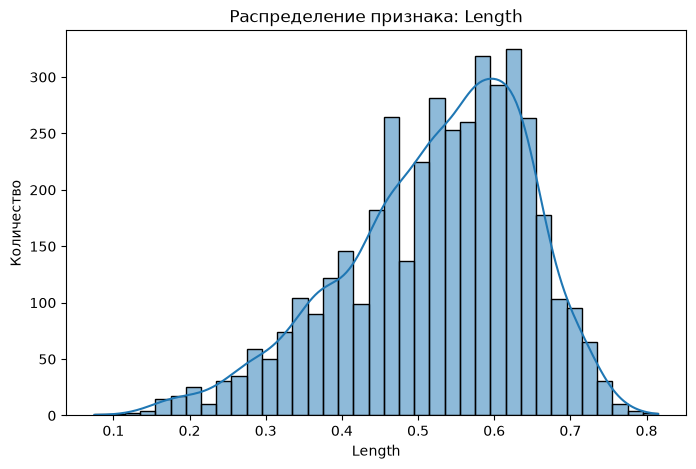

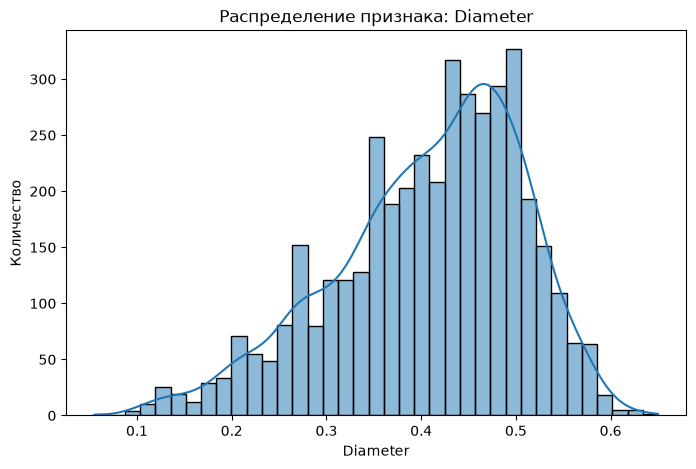

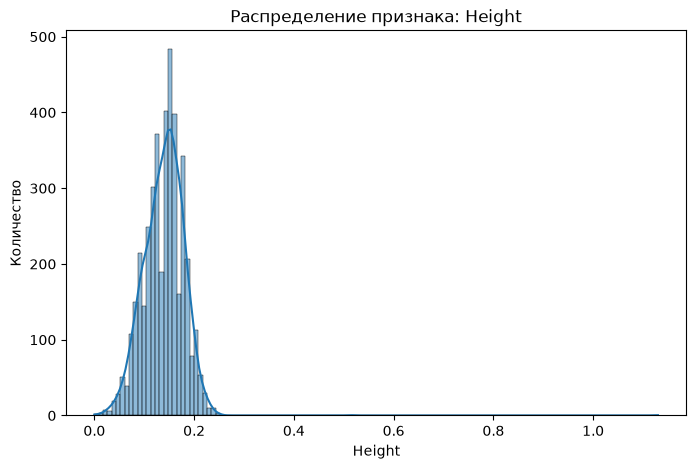

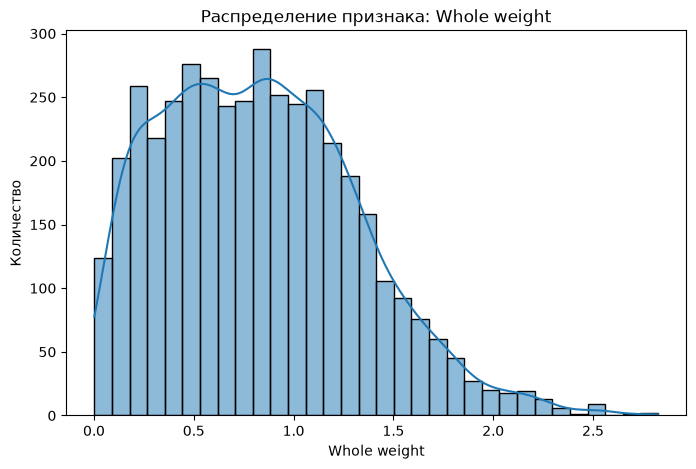

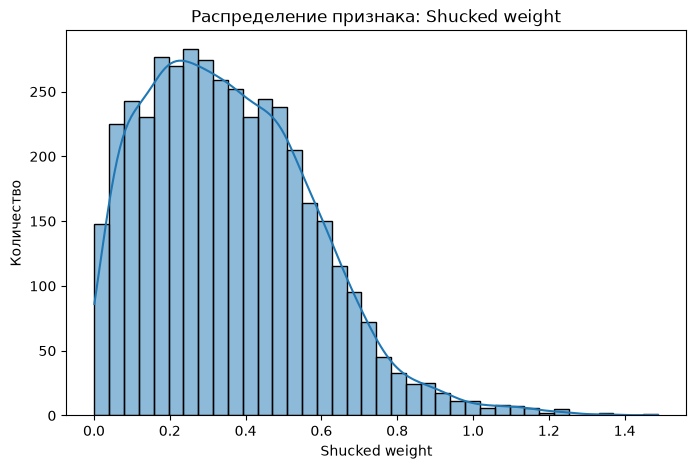

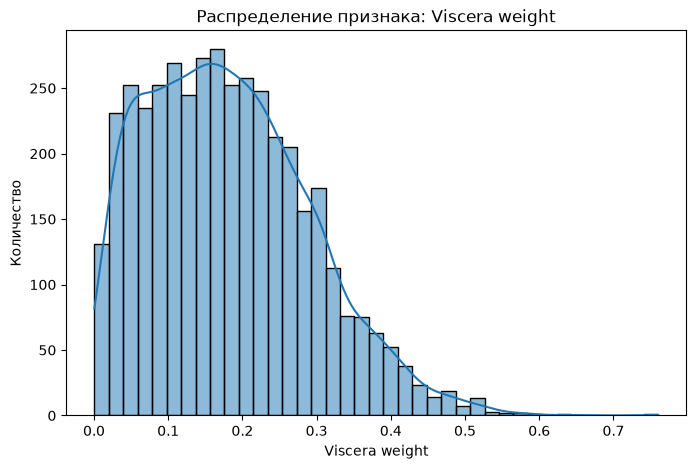

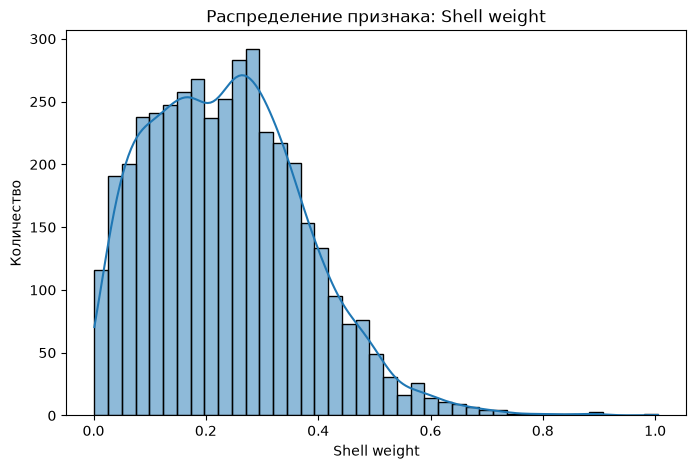

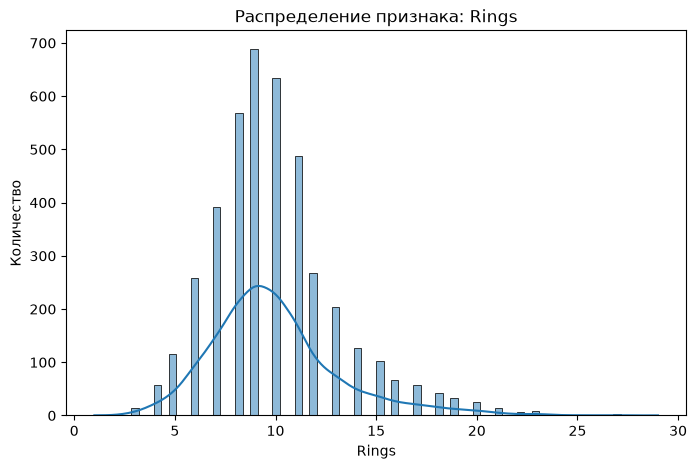

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.show()

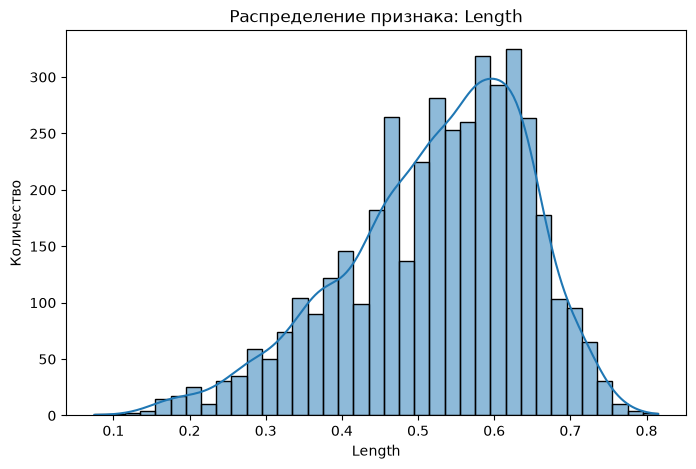

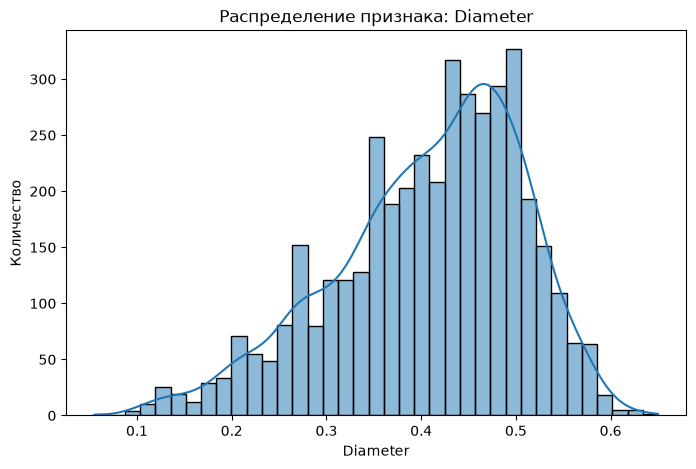

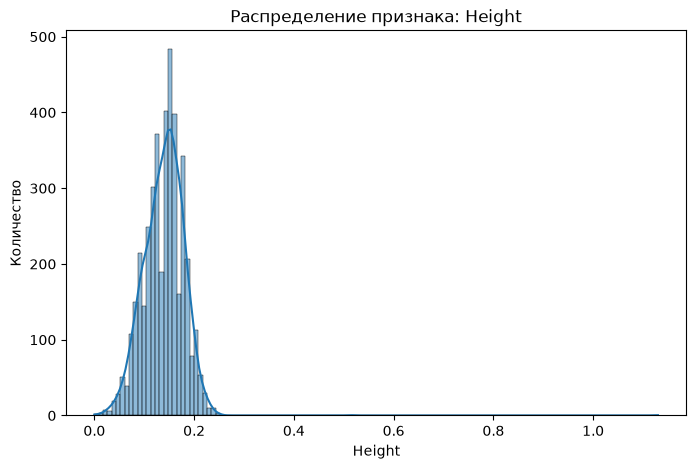

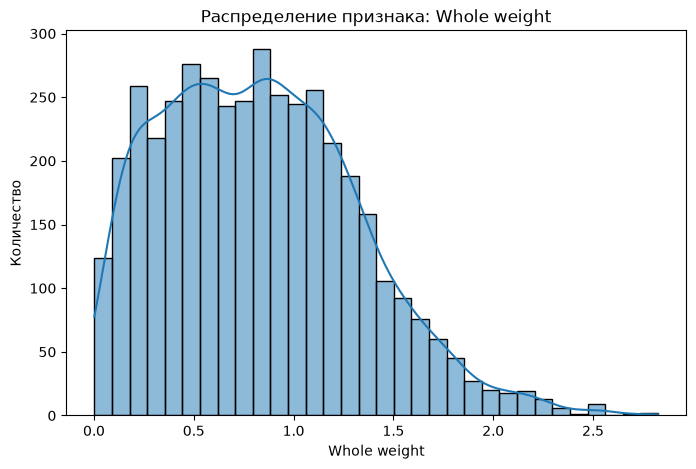

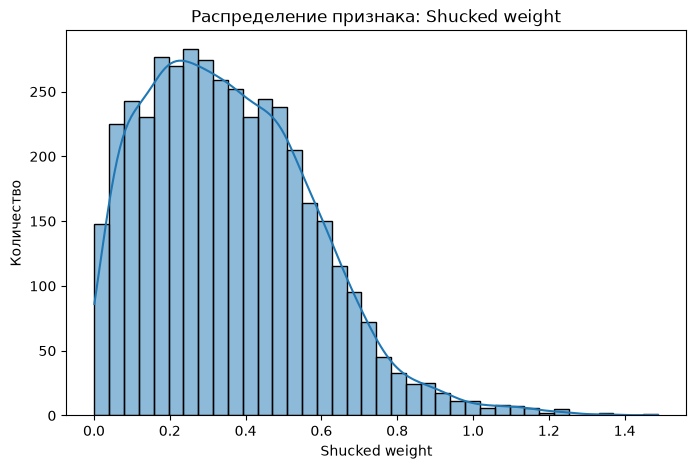

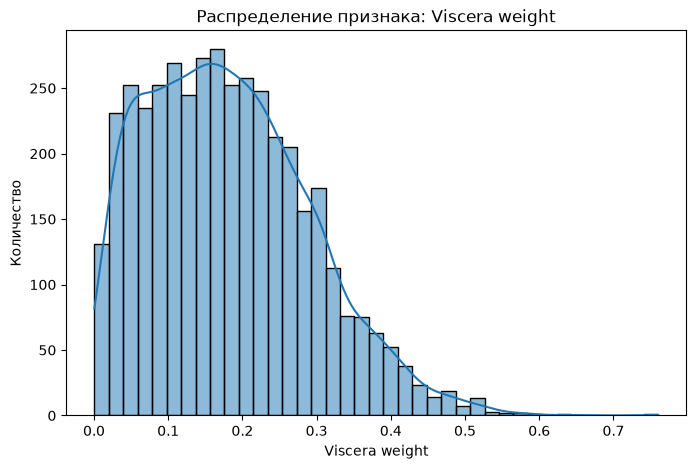

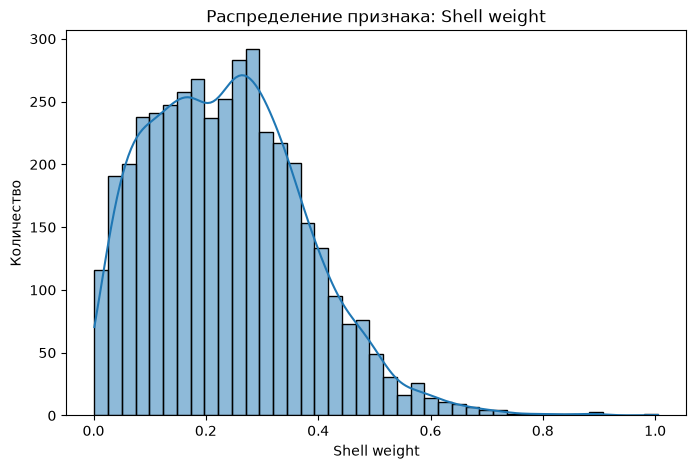

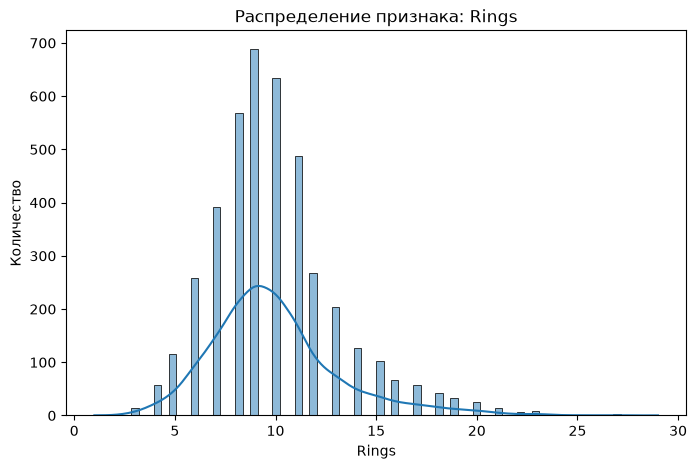

In [17]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.show()

In [18]:
outlier_info = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_info.append({
        "Признак": col,
        "Нижняя граница": lower,
        "Верхняя граница": upper,
        "Количество выбросов": outliers,
        "Процент": outliers / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df

,Признак,Нижняя граница,Верхняя граница,Количество выбросов,Процент
0,Length,0.20250,0.86250,49,1.173091
1,Diameter,0.15500,0.67500,59,1.412497
2,Height,0.04000,0.24000,29,0.694278
3,Whole weight,-0.62575,2.22025,30,0.718219
4,Shucked weight,-0.28800,0.97600,48,1.149150
5,Viscera weight,-0.14575,0.49225,26,0.622456
6,Shell weight,-0.16850,0.62750,35,0.837922
7,Rings,3.50000,15.50000,278,6.655494


# 3. Анализ категориальных признаков

In [19]:
for col in categorical_cols:
    print("=" * 50)
    print("Признак:", col)
    print("Количество уникальных значений:", df[col].nunique())
    print(df[col].value_counts(dropna=False))

Признак: gender
Количество уникальных значений: 3
gender
M    1528
I    1342
F    1307
Name: count, dtype: int64


In [20]:
for col in categorical_cols:
    print("=" * 50)
    print("Признак:", col)
    print((df[col].value_counts(normalize=True, dropna=False) * 100).round(2))

Признак: gender
gender
M    36.58
I    32.13
F    31.29
Name: proportion, dtype: float64


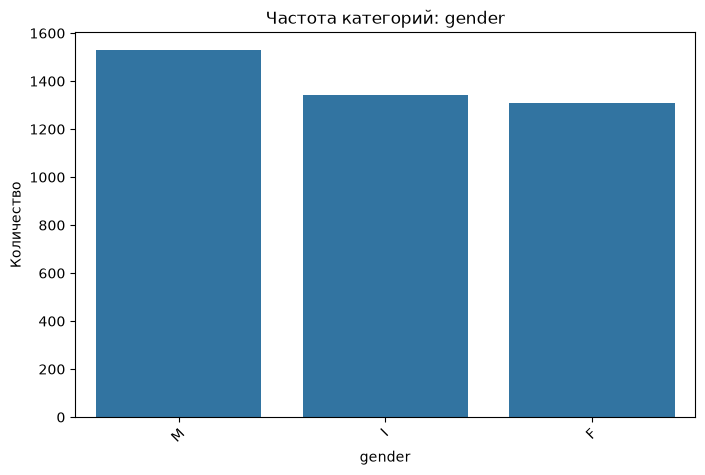

In [21]:
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    
    counts = df[col].fillna("Пропуск").value_counts()
    
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    
    plt.title(f"Частота категорий: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.xticks(rotation=45)
    plt.show()

# 4. Корреляционный анализ

In [22]:
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


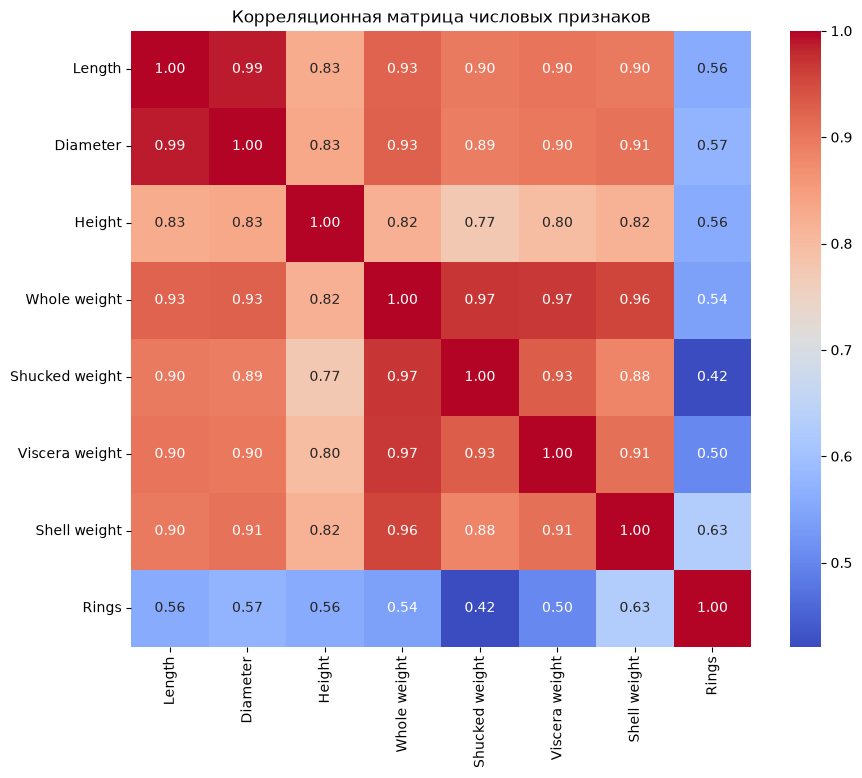

In [23]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [24]:
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=lambda x: abs(x),
    ascending=False
)

corr_pairs.head(10)

Length          Diameter          0.986812
Whole weight    Shucked weight    0.969405
                Viscera weight    0.966375
                Shell weight      0.955355
Shucked weight  Viscera weight    0.931961
Diameter        Whole weight      0.925452
Length          Whole weight      0.925261
Viscera weight  Shell weight      0.907656
Diameter        Shell weight      0.905330
Length          Viscera weight    0.903018
dtype: float64

In [25]:
top_pairs = corr_pairs.head(3)

top_pairs

Length        Diameter          0.986812
Whole weight  Shucked weight    0.969405
              Viscera weight    0.966375
dtype: float64

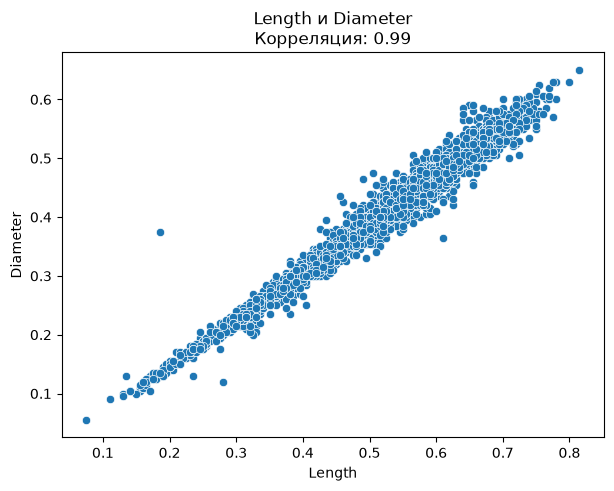

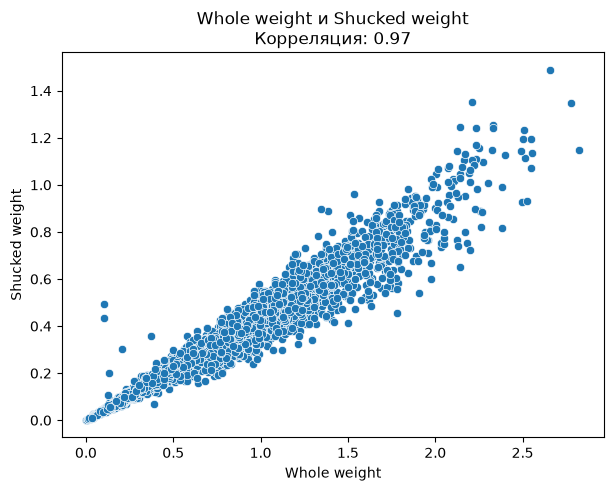

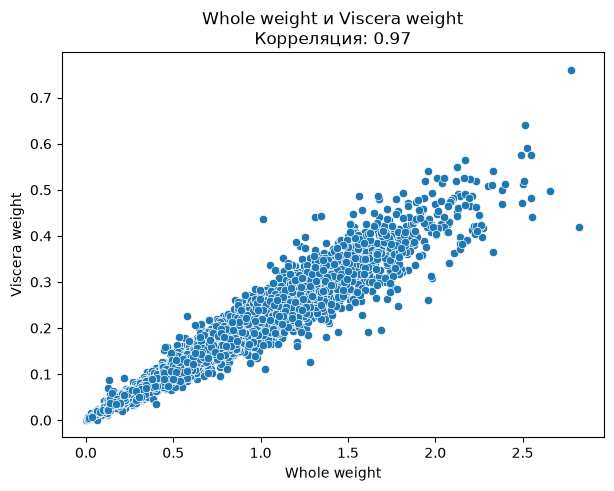

In [26]:
for (col1, col2), corr_value in top_pairs.items():
    plt.figure(figsize=(7, 5))
    
    sns.scatterplot(data=df, x=col1, y=col2)
    
    plt.title(
        f"{col1} и {col2}\nКорреляция: {corr_value:.2f}"
    )
    
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.show()

In [27]:
print(df.columns.tolist())

['gender', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']


In [28]:
target = "Rings"

In [29]:
print(df[target].value_counts(dropna=False))

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
1       1
26      1
29      1
2       1
25      1
Name: count, dtype: int64


In [30]:
print(
    (df[target].value_counts(normalize=True, dropna=False) * 100).round(2)
)

Rings
9     16.50
10    15.18
8     13.60
11    11.66
7      9.36
12     6.39
6      6.20
13     4.86
14     3.02
5      2.75
15     2.47
16     1.60
17     1.39
4      1.36
18     1.01
19     0.77
20     0.62
3      0.36
21     0.34
23     0.22
22     0.14
27     0.05
24     0.05
1      0.02
26     0.02
29     0.02
2      0.02
25     0.02
Name: proportion, dtype: float64


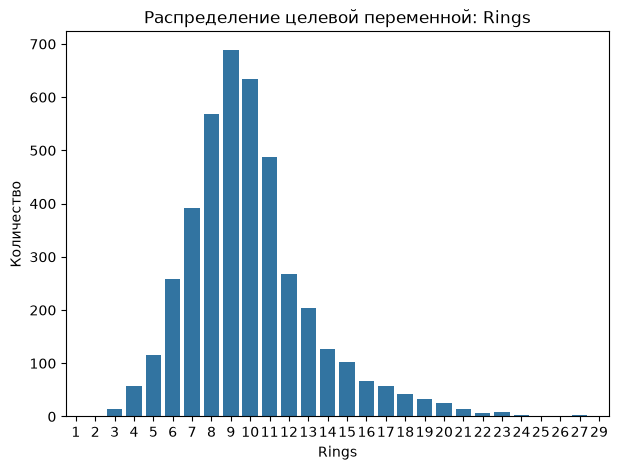

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=target)

plt.title(f"Распределение целевой переменной: {target}")
plt.xlabel(target)
plt.ylabel("Количество")
plt.show()

In [32]:
for col in numeric_cols:
    print(col, "минимум =", df[col].min())

Length минимум = 0.075
Diameter минимум = 0.055
Height минимум = 0.0
Whole weight минимум = 0.002
Shucked weight минимум = 0.001
Viscera weight минимум = 0.0005
Shell weight минимум = 0.0015
Rings минимум = 1


In [33]:
unique_info = pd.DataFrame({
    "Признак": df.columns,
    "Уникальных значений": [df[col].nunique() for col in df.columns]
})

unique_info

,Признак,Уникальных значений
0,gender,3
1,Length,134
2,Diameter,111
3,Height,51
4,Whole weight,2429
5,Shucked weight,1515
6,Viscera weight,880
7,Shell weight,926
8,Rings,28


# 5. Итоговый отчёт

1. В датасете не обнаружены пропущенные значения. Также было проверено наличие дубликатов.
2. Height имеет наиболее заметнюю ассиметрию с коэффицентом 3.128817
3. В нескольких числовых признаках обнаружены потенциальные выбросы по правилу IQR. На следующем этапе необходимо проверить, являются ли они реальными наблюдениями или ошибками.
4. Явно выраженной редкой категории не имеется
5. Между большинством физических признаков наблюдается сильная положительная корреляция. Наиболее сильная связь обнаружена между Length и Diameter (0.987). Также высокая корреляция наблюдается между Whole weight и отдельными составляющими веса: Shucked weight (0.969), Viscera weight (0.966) и Shell weight (0.955). Это означает, что увеличение одного из этих признаков обычно сопровождается увеличением другого. При построении моделей машинного обучения необходимо учитывать возможную мультиколлинеарность.
6. Целевая переменная не имеет выраженный дисбаланс классов
7. На следующем занятии предполагается обработать пропуски, проверить выбросы, объединить или обработать редкие категории и подготовить признаки для дальнейшего машинного обучения.